In [11]:
import os

DATASET_PATH = r"C:\Users\aishw\Downloads\covid\COVID-19_Radiography_Dataset"

print("DEBUG PATH =", DATASET_PATH)
print("Exists?", os.path.exists(DATASET_PATH))

DEBUG PATH = C:\Users\aishw\Downloads\covid\COVID-19_Radiography_Dataset
Exists? True


In [12]:
import os
print(os.listdir(r"c:\Users\aishw\Downloads\covid\Covid-19_Radiography_Dataset"))


# ================================================================
# IMPORT REQUIRED MODULES
# =================================================================

import os
import numpy as np
import torch
from torchvision import datasets, transforms, models
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

['COVID', 'COVID.metadata.xlsx', 'Lung_Opacity', 'Lung_Opacity.metadata.xlsx', 'Normal', 'Normal.metadata.xlsx', 'README.md.txt', 'Viral Pneumonia', 'Viral Pneumonia.metadata.xlsx']


In [13]:
#======================================================================
# DEVICE CONFIGURATION (CPU/GPU)
# =====================================================================

# Even though this is CNN-lite, feature extraction can still use GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print ("Using device:",device)

Using device: cpu


In [14]:
# =======================================================
# DATASET DIRECTORY
# =======================================================

# Change this path to where your Kaggle dataset is located
DATASET_PATH = r"c:\Users\aishw\Downloads\covid\COVID-19_Radiography_Dataset"

In [15]:
# ===========================================================
# IMAGE PREPROCESSING TRANSFORMATIONS
# ==========================================================

# Resize and normalize images so that they match ResNet input format
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

In [16]:
# =============================================================
# LOAD IMAGES FROM FOLDERS
# =============================================================

# ImageFolder automatically reads folder names as labels
dataset = datasets.ImageFolder(DATASET_PATH, transform=transform)

print ("Classes found in dataset:", dataset.classes)
print(dataset.classes)

Classes found in dataset: ['COVID', 'Lung_Opacity', 'Normal', 'Viral Pneumonia']
['COVID', 'Lung_Opacity', 'Normal', 'Viral Pneumonia']


In [17]:
# =============================================================
# LOAD PRETRAINED CNN AS FEATURE EXTRACTOR
# =============================================================

# We use ResNet18 but remove its classifier layer.
# It will only extract visual features from X-rays.

cnn_model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Remove last classification layer
feature_extractor = torch.nn.Sequential(*list(cnn_model.children())[:-1])

feature_extractor = feature_extractor.to(device)
feature_extractor.eval()

Sequential(
  (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Con

In [18]:
# ===================================================================
# EXTRACT FEATURES (MEMORY-SAFE VERSION)
# ===================================================================

from torch.utils.data import DataLoader

# Create DataLoader directly from dataset
loader = DataLoader(dataset, batch_size=32, shuffle=False)

features = []
labels_binary = []

with torch.no_grad():

    for imgs, lbls in loader:

        imgs = imgs.to(device)

        # Extract CNN features
        output = feature_extractor(imgs)

        #Flatten feature maps
        output = output.view(output.size(0), -1)

        features.append(output.cpu())

    # Convert labels to binary here
        for l in lbls:
            class_name = dataset.classes[l]   

            if "covid" in class_name.lower():
                labels_binary.append(1)
            else:
                labels_binary.append(0)

# Combine all batches
features = torch.cat(features).numpy()
labels = np.array(labels_binary)

print("Feature shape:", features.shape)
print("Unique labels:", np.unique(labels))

Feature shape: (42330, 512)
Unique labels: [0 1]


In [19]:
# ===========================================================
# TRAIN / TEST SPLIT
# ===========================================================

X_train,X_test,y_train,y_test = train_test_split(
    features, labels, test_size=0.2, random_state=42
)

In [20]:
# ==================================================
# TRAIN SCIKIT-LEARN CLASSIFIER
# ==================================================

# Logistic Regression is simple, fast and works well
# with extracted CNN features.

clf = LogisticRegression(max_iter=1000)

clf.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [21]:
# ================================================
# MODEL EVALUATION 
# ================================================

y_pred = clf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.891566265060241

Classification Report:

              precision    recall  f1-score   support

           0       0.90      0.97      0.94      6970
           1       0.80      0.51      0.63      1496

    accuracy                           0.89      8466
   macro avg       0.85      0.74      0.78      8466
weighted avg       0.89      0.89      0.88      8466



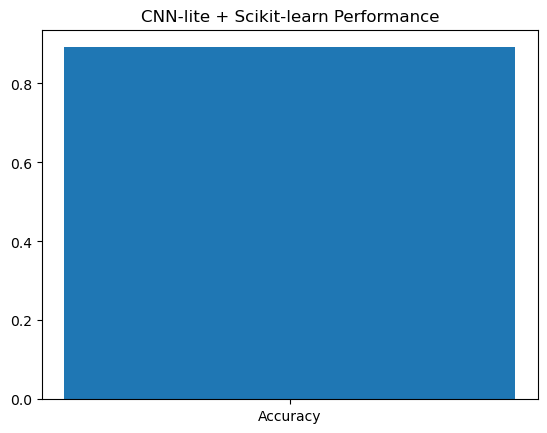

In [22]:
# ==========================================
# SIMPLE RESULT VISUALIZATION
# ==========================================

plt.bar(["Accuracy"], [accuracy])
plt.title("CNN-lite + Scikit-learn Performance")
plt.show()

In [23]:
# =============================================
# SAVE TRAINED MODEL
# =============================================

import joblib

joblib.dump(clf, "covid_classifier_sklearn.pkl")

print(" Scikit-learn model saved successfully!")


 Scikit-learn model saved successfully!
